In [7]:
import numpy as np
import pandas as pd
from cyvcf2 import VCF
import os
from scipy import stats
from qqman import qqman
import matplotlib.pyplot as plt

In [8]:
# Class Dataset
phenotype_file = "~/public/ps3/ps3_gwas.phen"
vcf_file = os.path.expanduser("~/public/ps3/ps3_gwas.vcf.gz")
covar_file = "/home/sgaywala/ps3-wi26/ps3_gwas.eigenvec"
covar_file = os.path.expanduser(covar_file)
covar_df = pd.read_csv(covar_file, delim_whitespace=True, header=None)
covariate_matrix = covar_df.iloc[:, 2:].values

In [ ]:
def gwas_linear(G, y):
    """
    G: (n_samples, n_snps)
    y: (n_samples,)
    Returns: beta, pvals
    """
    n = G.shape[0]

    # Center variables (important!)
    G_centered = G - G.mean(axis=0)
    y_centered = y - y.mean()

    # Compute beta for each SNP
    numerator = np.sum(G_centered * y_centered[:, None], axis=0)
    denominator = np.sum(G_centered**2, axis=0)
    beta = numerator / denominator

    # Predicted values
    y_hat = G_centered * beta

    # Residual variance
    rss = np.sum((y_centered[:, None] - y_hat)**2, axis=0)
    sigma2 = rss / (n - 2)

    # Standard error
    se = np.sqrt(sigma2 / denominator)

    # t-statistic
    t_stat = beta / se

    # Two-sided p-value
    pvals = 2 * stats.t.sf(np.abs(t_stat), df=n-2)

    return beta, pvals

def gwas_linear_cov(G, y, C):
    """
    G: (n_samples, n_snps)
    y: (n_samples,)
    C: (n_samples, n_covariates)

    Returns:
        beta (n_snps,)
        pvals (n_snps,)
    """

    n = G.shape[0]

    # Add intercept to covariates
    C = np.column_stack((np.ones(n), C))

    # Precompute projection matrix components
    CtC_inv = np.linalg.inv(C.T @ C)
    P = C @ CtC_inv @ C.T   # projection onto covariates

    # Residualize phenotype
    y_res = y - P @ y

    # Residualize genotypes
    G_res = G - P @ G

    # Now run simple regression on residuals
    numerator = np.sum(G_res * y_res[:, None], axis=0)
    denominator = np.sum(G_res**2, axis=0)
    beta = numerator / denominator

    # Residual variance
    y_hat = G_res * beta
    rss = np.sum((y_res[:, None] - y_hat)**2, axis=0)

    df = n - C.shape[1] - 1
    sigma2 = rss / df

    se = np.sqrt(sigma2 / denominator)

    t_stat = beta / se
    pvals = 2 * stats.t.sf(np.abs(t_stat), df=df)

    return beta, pvals

def gwas_fxn_cov(vcf_file: str, phenotype_file: str, covariate_matrix = None):
    vcf = VCF(vcf_file)
    
    # read phenotypes
    phen_df = pd.read_csv(phenotype_file, delim_whitespace=True, header=None)
    phen_df.columns = ["FID", "IID", "PHENO"]
    
    # read genotypes
    sample_ids = np.array(vcf.samples)
    n_samples = len(sample_ids)
    print("Number of individuals in VCF:", n_samples)
    
    genotypes = []
    chroms = []
    positions = []

    for variant in vcf:
        # variant.genotypes gives [ [0,1,True], ... ]
        # first two entries are alleles
        gt = np.array([g[0] + g[1] if g[0] != -1 else np.nan 
                       for g in variant.genotypes])
        genotypes.append(gt)
        chroms.append(variant.CHROM)
        positions.append(variant.POS)

    G = np.array(genotypes).T  # transpose to get individuals x SNPs
    
    print("# individuals x # SNPs")
    print(G.shape) # individuals x SNPs
    
    # Align Phenotypes
    phenotypes = phen_df["PHENO"].values
    phenotype_ids = phen_df["IID"].values
    id_to_pheno = dict(zip(phenotype_ids, phenotypes))

    aligned_phenotypes = np.array([id_to_pheno[s] for s in sample_ids])
    aligned_phenotypes = np.array(aligned_phenotypes, dtype=float)
    
    if covariate_matrix is None:
        beta, pvals = gwas_linear(G, aligned_phenotypes)
    else:
        beta, pvals = gwas_linear_cov(G, aligned_phenotypes, covariate_matrix)
    
    assoc_df = pd.DataFrame({
        "CHR": chroms,
        "BP": positions,
        "BETA": beta,
        "P": pvals
    })
    assoc_df["CHR"] = pd.to_numeric(assoc_df["CHR"], errors="coerce")
    assoc_df = assoc_df.sort_values(["CHR", "BP"]).reset_index(drop=True)

    print(assoc_df.head())
    
    fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
    fig.set_size_inches((15, 5))
    qqman.manhattan(assoc_df, ax=ax0)
    qqman.qqplot(assoc_df, ax=ax1)

Number of individuals in VCF: 207
# individuals x # SNPs
(207, 917845)
   CHR      BP      BETA             P
0    1  752566 -0.302728  5.049645e-04
1    1  752721 -0.407888  9.056280e-07
2    1  776546 -0.462037  4.919576e-04
3    1  798959  0.296714  4.859662e-04
4    1  800007 -0.570414  9.751824e-03
[WARNING]: Column 'SNP' not found!


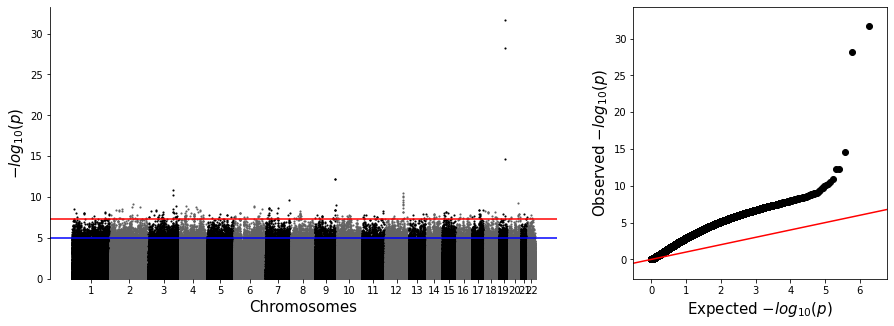

In [9]:
gwas_fxn_cov(vcf_file, phenotype_file, covariate_matrix = None)

Number of individuals in VCF: 207
# individuals x # SNPs
(207, 917845)
   CHR      BP      BETA         P
0    1  752566 -0.054095  0.610764
1    1  752721 -0.218377  0.061953
2    1  776546 -0.162870  0.275370
3    1  798959 -0.026703  0.824523
4    1  800007 -0.222533  0.316102
[WARNING]: Column 'SNP' not found!


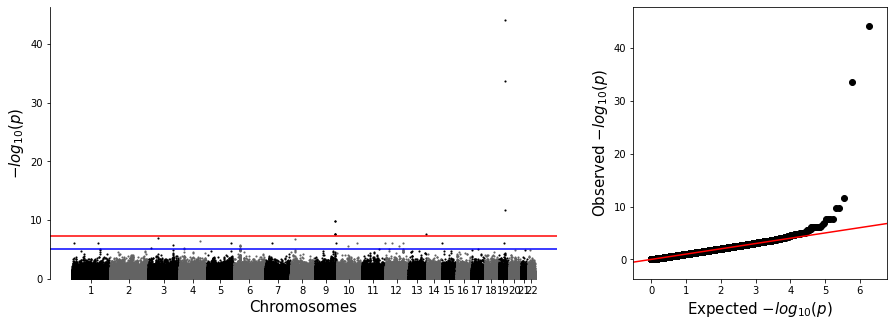

In [10]:
gwas_fxn_cov(vcf_file, phenotype_file, covariate_matrix)

In [17]:
# Positive Dataset
phenotype_file = os.path.expanduser("~/private/CSE284/final_project/small_test_data/positive_control.phen")
vcf_file = os.path.expanduser("~/private/CSE284/final_project/genotype_subset.vcf.gz")
covar_file = "~/private/CSE284/final_project/small_test_data/samples.covar"

covar_file = os.path.expanduser(covar_file)
covar_df = pd.read_csv(covar_file, delim_whitespace=True, header=None)
covariate_matrix = covar_df.iloc[:, 2:].values
covariate_matrix = covariate_matrix[1:, :].astype(float)
covariate_matrix


array([[1., 0., 0., ..., 0., 0., 0.],
       [2., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [2., 0., 0., ..., 0., 0., 0.],
       [2., 0., 0., ..., 0., 0., 0.]])

In [18]:
# run PCA on these samples and plot
vcf = VCF(vcf_file)

# read phenotypes
phen_df = pd.read_csv(phenotype_file, delim_whitespace=True, header=None)
phen_df.columns = ["FID", "IID", "PHENO"]

# read genotypes
sample_ids = np.array(vcf.samples)
n_samples = len(sample_ids)
print("Number of individuals in VCF:", n_samples)

genotypes = []
chroms = []
positions = []

for variant in vcf:
    # variant.genotypes gives [ [0,1,True], ... ]
    # first two entries are alleles
    gt = np.array([g[0] + g[1] if g[0] != -1 else np.nan 
                   for g in variant.genotypes])
    genotypes.append(gt)
    chroms.append(variant.CHROM)
    positions.append(variant.POS)

G = np.array(genotypes).T  # transpose to get individuals x SNPs

print("# individuals x # SNPs")
print(G.shape) # individuals x SNPs

G

Number of individuals in VCF: 200
# individuals x # SNPs
(200, 49635)


array([[0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [1, 1, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 0, ..., 0, 1, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [19]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- Inputs ---
# G: genotype matrix, shape (n_individuals, n_snps)
# metadata_file: path to metadata file

# Example:
# G = np.load("genotypes.npy")  # or however you have it loaded
# metadata_file = "metadata.tsv"

# --- Read metadata ---
meta = pd.read_csv(covar_file, sep='\t')

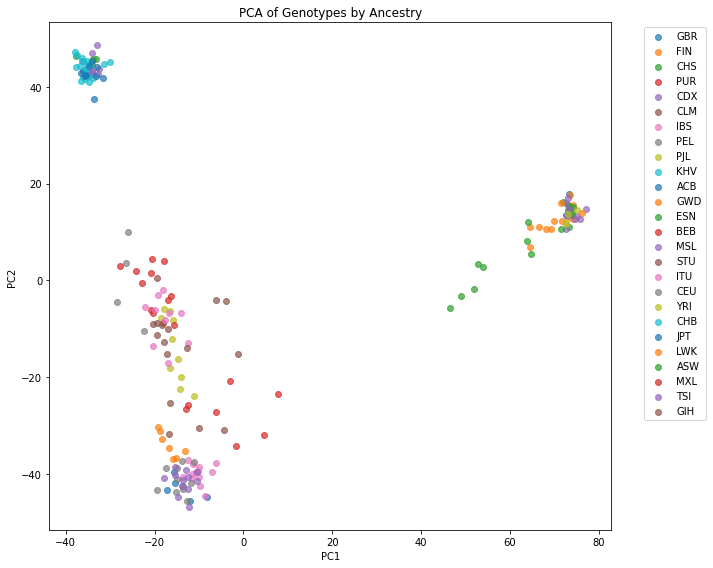

In [33]:
pop_cols = [c for c in meta.columns if c.startswith("pop_")]

# Get the column name of the ancestry (the one with 1)
def get_ancestry(row):
    # If multiple 1's exist, take first
    for col in pop_cols:
        if row[col] == 1:
            return col.replace("pop_", "")
    return "Unknown"

meta["ancestry"] = meta.apply(get_ancestry, axis=1)

# --- Run PCA ---
pca = PCA(n_components=4)
pcs = pca.fit_transform(G)  # shape (n_individuals, 2)

# --- Make a DataFrame for plotting ---
pc_df = pd.DataFrame({
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1],
    "ancestry": meta["ancestry"]
})

# --- Plot ---
plt.figure(figsize=(10,8))
for ancestry in pc_df["ancestry"].unique():
    subset = pc_df[pc_df["ancestry"] == ancestry]
    plt.scatter(subset["PC1"], subset["PC2"], label=ancestry, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Genotypes by Ancestry")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



In [34]:
covariate_matrix = pcs[:, :4]
covariate_matrix

array([[-1.53774015e+01, -4.17888719e+01, -1.02591301e+01,
        -6.61739585e+00],
       [-1.19743704e+01, -4.55568605e+01, -1.23527882e+01,
        -7.16871849e+00],
       [-1.83949528e+01, -3.27025030e+01, -1.23846521e+01,
        -6.68759294e+00],
       [-1.56384981e+01, -3.95656455e+01, -8.34668430e+00,
        -5.50974280e+00],
       [-8.30879553e+00, -4.47934969e+01, -1.34019580e+01,
        -8.43219357e+00],
       [-1.57999287e+01, -3.68246420e+01, -8.62387513e+00,
        -3.53517533e+00],
       [-1.51676200e+01, -3.67124389e+01, -9.97438972e+00,
        -1.29218169e+01],
       [-1.87855859e+01, -3.10738158e+01, -7.10141795e+00,
        -3.86883405e+00],
       [-1.32644957e+01, -3.53176861e+01, -1.04018245e+01,
        -1.53077380e+00],
       [-1.91791515e+01, -3.01795326e+01, -5.46215124e+00,
        -3.30612641e+00],
       [-1.67791262e+01, -3.45698615e+01, -5.73205146e+00,
        -8.94399106e+00],
       [-3.41268092e+01,  4.44508740e+01, -6.11952089e+00,
      

Number of individuals in VCF: 200
# individuals x # SNPs
(200, 49635)
   CHR      BP      BETA         P
0   10   98087  0.024567  0.868795
1   10  111955 -0.219915  0.446299
2   10  126070 -0.479626  0.000850
3   10  134767  0.264726  0.037171
4   10  135656  0.055980  0.702016
[WARNING]: Column 'SNP' not found!


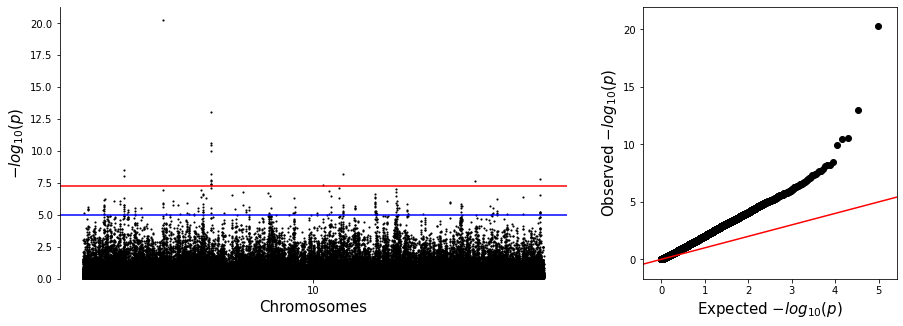

In [35]:
gwas_fxn_cov(vcf_file, phenotype_file, covariate_matrix = None)

Number of individuals in VCF: 200
# individuals x # SNPs
(200, 49635)
   CHR      BP      BETA         P
0   10   98087  0.069730  0.626722
1   10  111955 -0.309528  0.256963
2   10  126070 -0.039445  0.813138
3   10  134767  0.047624  0.709563
4   10  135656  0.057661  0.682973
[WARNING]: Column 'SNP' not found!


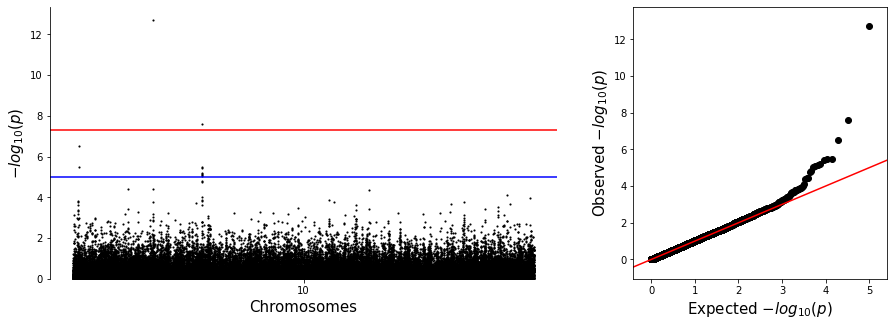

In [36]:
gwas_fxn_cov(vcf_file, phenotype_file, covariate_matrix = covariate_matrix)

In [37]:
# Negative Dataset
phenotype_file = os.path.expanduser("~/private/CSE284/final_project/small_test_data/negative_control.phen")
vcf_file = os.path.expanduser("~/private/CSE284/final_project/genotype_subset.vcf.gz")

Number of individuals in VCF: 200
# individuals x # SNPs
(200, 49635)
   CHR      BP      BETA         P
0   10   98087  0.102132  0.315517
1   10  111955  0.179951  0.362817
2   10  126070 -0.087811  0.378860
3   10  134767  0.028260  0.746696
4   10  135656  0.089539  0.371290
[WARNING]: Column 'SNP' not found!


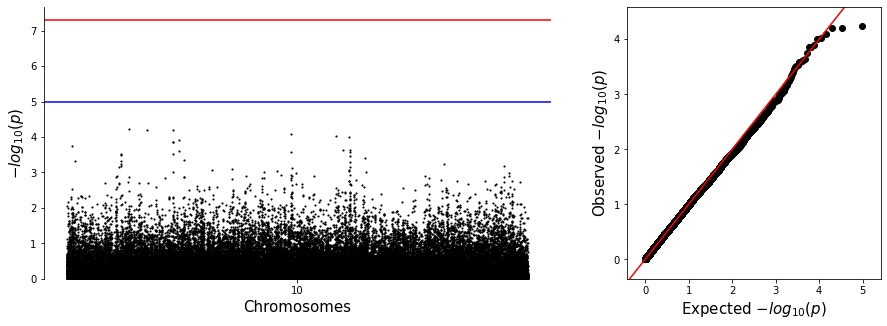

In [38]:
gwas_fxn_cov(vcf_file, phenotype_file, covariate_matrix = None)

Number of individuals in VCF: 200
# individuals x # SNPs
(200, 49635)
   CHR      BP      BETA         P
0   10   98087  0.111048  0.296812
1   10  111955  0.179250  0.377385
2   10  126070 -0.211592  0.086812
3   10  134767  0.056692  0.550694
4   10  135656  0.100910  0.335729
[WARNING]: Column 'SNP' not found!


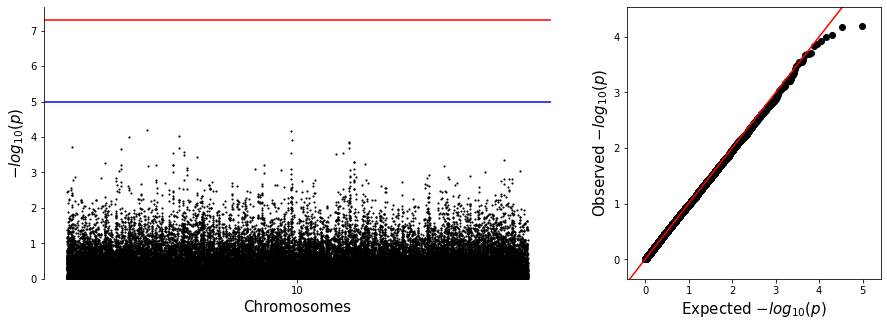

In [39]:
gwas_fxn_cov(vcf_file, phenotype_file, covariate_matrix = covariate_matrix)